In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

LoadError: ArgumentError: Package pandas not found in current path.
- Run `import Pkg; Pkg.add("pandas")` to install the pandas package.

In [ ]:
df = pd.read_csv('/kaggle/input/cricket-dataset/final_ball_by_ball_first_innings.csv')

In [ ]:
# Extract and label encode venues
venues = df['venue'].unique()
venue_encoder = LabelEncoder()
venue_encoder.fit(venues)
df['venue_encoded'] = venue_encoder.transform(df['venue'])

# print("Venues:", venues)
print(f"Number of unique venues: {len(venues)}\n")

# Extract list of players (union of batter, bowler, non_striker)
players = pd.concat([
    df['batter'],
    df['bowler'],
    df['non_striker']
]).unique()

# Label encode players
player_encoder = LabelEncoder()
player_encoder.fit(players)
df['batter_encoded'] = player_encoder.transform(df['batter'])
df['bowler_encoded'] = player_encoder.transform(df['bowler'])
df['non_striker_encoded'] = player_encoder.transform(df['non_striker'])

# print("Players:", players)
print(f"Number of unique players: {len(players)}\n")

# Cumulative team score and wickets per match
df["score_till"] = df.groupby(["match_id"])["runs_total"].cumsum()
df["wickets_fallen"] = df.groupby(["match_id"])["wicket_fallen"].cumsum()

# Batter cumulative stats per match
df["batter_score"] = df.groupby(["match_id", "batter_encoded"])["runs_batter"].cumsum()
df["batter_ball_faced"] = df.groupby(["match_id", "batter_encoded"]).cumcount() + 1

# Bowler cumulative stats per match
df["bowler_bowled_balls"] = df.groupby(["match_id", "bowler_encoded"]).cumcount() + 1
df["bowler_wicket_taken"] = df.groupby(["match_id", "bowler_encoded"])["wicket_fallen"].cumsum()

Number of unique venues: 446

Number of unique players: 6252



In [ ]:
# Add bowler_runs_conceded column (cumulative runs conceded by bowler per match)
df["bowler_runs_conceded"] = df.groupby(["match_id", "bowler_encoded"])["runs_total"].cumsum()

print("Added bowler_runs_conceded column")
print(df[['bowler_encoded', 'runs_total', 'bowler_runs_conceded']].head(20))

Added bowler_runs_conceded column
    bowler_encoded  runs_total  bowler_runs_conceded
0             5183           0                     0
1             5183           0                     0
2             5183           1                     1
3             5183           2                     3
4             5183           0                     3
5             5183           3                     6
6             2826           0                     0
7             2826           1                     1
8             2826           0                     1
9             2826           0                     1
10            2826           4                     5
11            2826           2                     7
12            2561           1                     1
13            2561           1                     2
14            2561           0                     2
15            2561           0                     2
16            2561           4                     6
17          

In [ ]:
df.drop(columns=["venue", "batter", "bowler", "non_striker", "team","innings"], inplace=True)

In [ ]:
# Verify all new columns created
print("\nDataFrame columns:")
print(df.columns.tolist())
print(f"\nDataFrame shape: {df.shape}")

print("\n\nSample output with cumulative stats:")
print(df.head(15))


DataFrame columns:
['match_id', 'date', 'over', 'ball', 'runs_batter', 'runs_extras', 'runs_total', 'wicket_fallen', 'venue_encoded', 'batter_encoded', 'bowler_encoded', 'non_striker_encoded', 'score_till', 'wickets_fallen', 'batter_score', 'batter_ball_faced', 'bowler_bowled_balls', 'bowler_wicket_taken', 'bowler_runs_conceded']

DataFrame shape: (599294, 19)


Sample output with cumulative stats:
    match_id        date  over  ball  runs_batter  runs_extras  runs_total  \
0    1001349  2017-02-17     0     1            0            0           0   
1    1001349  2017-02-17     0     2            0            0           0   
2    1001349  2017-02-17     0     3            1            0           1   
3    1001349  2017-02-17     0     4            2            0           2   
4    1001349  2017-02-17     0     5            0            0           0   
5    1001349  2017-02-17     0     6            3            0           3   
6    1001349  2017-02-17     1     1            0  

In [ ]:
# Save the processed dataframe to CSV
df.to_csv('processed_data.csv', index=False)
print("Processed data saved to 'processed_data.csv'")
print(f"File size: {pd.read_csv('processed_data.csv').shape}")

Processed data saved to 'processed_data.csv'
File size: (599294, 19)


In [ ]:
# Create output dataframe with match_id and total_score
output_df = df.groupby('match_id')['score_till'].max().reset_index()
output_df.columns = ['match_id', 'total_score']

print("Output dataframe:")
print(output_df.head(10))
print(f"\nShape: {output_df.shape}")

# Save output to CSV
output_df.to_csv('match_total_scores.csv', index=False)
print("\nOutput saved to 'match_total_scores.csv'")

Output dataframe:
   match_id  total_score
0    211028          179
1    211048          214
2    222678          133
3    225263          144
4    225271          163
5    226374          209
6    237242          126
7    238195          201
8    249227          221
9    251487          162

Shape: (4913, 2)

Output saved to 'match_total_scores.csv'


In [ ]:
df.head()

,match_id,date,over,ball,runs_batter,runs_extras,runs_total,wicket_fallen,venue_encoded,batter_encoded,bowler_encoded,non_striker_encoded,score_till,wickets_fallen,batter_score,batter_ball_faced,bowler_bowled_balls,bowler_wicket_taken,bowler_runs_conceded
0,1001349,2017-02-17,0,1,0,0,0,0,232,333,5183,3241,0,0,0,1,1,0,0
1,1001349,2017-02-17,0,2,0,0,0,0,232,333,5183,3241,0,0,0,2,2,0,0
2,1001349,2017-02-17,0,3,1,0,1,0,232,333,5183,3241,1,0,1,3,3,0,1
3,1001349,2017-02-17,0,4,2,0,2,0,232,3241,5183,333,3,0,2,1,4,0,3
4,1001349,2017-02-17,0,5,0,0,0,0,232,3241,5183,333,3,0,2,2,5,0,3


In [ ]:
# Prepare data for deep learning model with PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Drop match_id column
df_model = df.drop(columns=['date'])

# Create target variable: map outcomes to classes
# Classes: 0, 1, 2, 3, 4, 6, W (wicket)
def get_ball_outcome(row):
    if row['wicket_fallen'] == 1:
        return 6  # W (wicket) is mapped to index 6
    else:
        runs = row['runs_batter']
        if runs == 0:
            return 0
        elif runs == 1:
            return 1
        elif runs == 2:
            return 2
        elif runs == 3:
            return 3
        elif runs == 4:
            return 4
        elif runs == 6:
            return 5
        else:
            return 0  # Default to 0 for any other value

df_model['outcome'] = df_model.apply(get_ball_outcome, axis=1)

# Shift cumulative columns to get values BEFORE current ball
df_model['score_till_before'] = df_model.groupby('match_id')['score_till'].shift(1).fillna(0)
df_model['wickets_fallen_before'] = df_model.groupby('match_id')['wickets_fallen'].shift(1).fillna(0)
df_model['batter_score_before'] = df_model.groupby(['match_id', 'batter_encoded'])['batter_score'].shift(1).fillna(0)
df_model['batter_ball_faced_before'] = df_model.groupby(['match_id', 'batter_encoded'])['batter_ball_faced'].shift(1).fillna(0)
df_model['bowler_bowled_balls_before'] = df_model.groupby(['match_id', 'bowler_encoded'])['bowler_bowled_balls'].shift(1).fillna(0)
df_model['bowler_wicket_taken_before'] = df_model.groupby(['match_id', 'bowler_encoded'])['bowler_wicket_taken'].shift(1).fillna(0)
df_model['bowler_runs_conceded_before'] = df_model.groupby(['match_id', 'bowler_encoded'])['bowler_runs_conceded'].shift(1).fillna(0)

print("Target variable distribution:")
print(df_model['outcome'].value_counts().sort_index())
print(f"\nClass mapping: 0=0runs, 1=1run, 2=2runs, 3=3runs, 4=4runs, 5=6runs, 6=Wicket")

Target variable distribution:
outcome
0    249940
1    198254
2     43405
3      2827
4     53636
5     17989
6     33243
Name: count, dtype: int64

Class mapping: 0=0runs, 1=1run, 2=2runs, 3=3runs, 4=4runs, 5=6runs, 6=Wicket


In [ ]:
# Prepare features and target for model
input_features = ['over', 'ball', 'venue_encoded', 'batter_encoded', 'bowler_encoded', 
                  'non_striker_encoded', 'score_till_before', 'wickets_fallen_before', 
                  'batter_score_before', 'batter_ball_faced_before', 'bowler_bowled_balls_before',
                  'bowler_runs_conceded_before', 'bowler_wicket_taken_before']

X = df_model[input_features].values
y = df_model['outcome'].values

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Input features: {input_features}")

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

print(f"\nTrain set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Features shape: (599294, 13)
Target shape: (599294,)
Number of classes: 7
Input features: ['over', 'ball', 'venue_encoded', 'batter_encoded', 'bowler_encoded', 'non_striker_encoded', 'score_till_before', 'wickets_fallen_before', 'batter_score_before', 'batter_ball_faced_before', 'bowler_bowled_balls_before', 'bowler_runs_conceded_before', 'bowler_wicket_taken_before']

Train set size: 479435
Test set size: 119859


In [ ]:
# Define PyTorch Neural Network
class BallOutcomePredictor(nn.Module):
    def __init__(self, input_size, num_classes=7):
        super(BallOutcomePredictor, self).__init__()
        self.fc1 = nn.Linear(input_size, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.dropout1 = nn.Dropout(0.3)
        
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(0.3)
        
        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.dropout3 = nn.Dropout(0.2)
        
        self.fc4 = nn.Linear(64, num_classes)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)
        
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)
        
        x = self.relu(self.bn3(self.fc3(x)))
        x = self.dropout3(x)
        
        x = self.fc4(x)  # Output logits
        return x

# Initialize model, loss function, and optimizer
input_size = len(input_features)
num_classes = 7
model = BallOutcomePredictor(input_size, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Model initialized")
print(f"Model architecture:\n{model}")

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"\nUsing device: {device}")

Model initialized
Model architecture:
BallOutcomePredictor(
  (fc1): Linear(in_features=13, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout3): Dropout(p=0.2, inplace=False)
  (fc4): Linear(in_features=64, out_features=7, bias=True)
  (relu): ReLU()
)

Using device: cuda


In [ ]:
# Create data loaders
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Training function
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        # Forward pass
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()
    
    return total_loss / len(train_loader), correct / total

# Evaluation function
def evaluate(model, test_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    
    return total_loss / len(test_loader), correct / total

# Train the model
num_epochs = 10
for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    
    if (epoch + 1) % 2 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}')

print("\nTraining completed!")

Epoch [2/10] - Train Loss: 1.3810, Train Acc: 0.4587, Test Loss: 1.3779, Test Acc: 0.4548
Epoch [4/10] - Train Loss: 1.3773, Train Acc: 0.4600, Test Loss: 1.3728, Test Acc: 0.4621
Epoch [6/10] - Train Loss: 1.3757, Train Acc: 0.4605, Test Loss: 1.3727, Test Acc: 0.4615
Epoch [8/10] - Train Loss: 1.3750, Train Acc: 0.4605, Test Loss: 1.3727, Test Acc: 0.4586
Epoch [10/10] - Train Loss: 1.3746, Train Acc: 0.4601, Test Loss: 1.3715, Test Acc: 0.4621

Training completed!


In [ ]:
# Function to get probability predictions
def predict_with_probabilities(model, X, device):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.FloatTensor(X).to(device)
        outputs = model(X_tensor)
        probabilities = nn.functional.softmax(outputs, dim=1)
    return probabilities.cpu().numpy()

# Make predictions on test set
test_probabilities = predict_with_probabilities(model, X_test, device)

print("Prediction probabilities shape:", test_probabilities.shape)
print("\nFirst 5 predictions (probability arrays):")
print(test_probabilities[:5])
print("\nClass probabilities for first test sample:")
class_names = ['0 runs', '1 run', '2 runs', '3 runs', '4 runs', '6 runs', 'Wicket']
for i, prob in enumerate(test_probabilities[0]):
    print(f"  {class_names[i]}: {prob:.4f}")

# Save the model
torch.save(model.state_dict(), 'ball_outcome_model.pth')
print("\nModel saved to 'ball_outcome_model.pth'")

Prediction probabilities shape: (119859, 7)

First 5 predictions (probability arrays):
[[0.5900226  0.2240485  0.05350103 0.00525871 0.07368648 0.00762698
  0.04585566]
 [0.3525471  0.4009976  0.08813082 0.00383744 0.07452701 0.01712445
  0.06283557]
 [0.5363226  0.283933   0.05731804 0.00342069 0.05616162 0.00865976
  0.0541843 ]
 [0.45919564 0.3320972  0.07122552 0.00382836 0.06519691 0.01038961
  0.05806678]
 [0.6017865  0.1954231  0.05304314 0.00578202 0.09065554 0.00842521
  0.04488451]]

Class probabilities for first test sample:
  0 runs: 0.5900
  1 run: 0.2240
  2 runs: 0.0535
  3 runs: 0.0053
  4 runs: 0.0737
  6 runs: 0.0076
  Wicket: 0.0459

Model saved to 'ball_outcome_model.pth'


# Model Accuracy Improvement Suggestions

## Current Issues:

### 🔴 CRITICAL BUG in Data Preparation:
- **Shifting by 'date' is wrong!** Should shift by 'match_id' to get "before" values from same match
- This causes data leakage and incorrect feature values

### Dataset Improvements:

1. **Fix the shifting logic** (use match_id instead of date)
2. **Add more features:**
   - Current run rate (score_till / balls_bowled)
   - Recent form: last 6 balls runs, last over runs
   - Phase of innings: powerplay (0-6), middle (7-15), death (16-20)
   - Balls remaining in innings
   - Batter strike rate, bowler economy rate
   - Venue average score
   - Day/night match indicator
   
3. **Handle class imbalance:**
   - Use class weights in loss function
   - SMOTE oversampling for minority classes
   - Focal loss instead of CrossEntropy

4. **Missing outcome:** Include 5 runs (rare but exists)

5. **Feature engineering:**
   - Interaction features (batter vs bowler matchup)
   - Rolling statistics (last 5 overs run rate)
   - Pressure indicators (wickets in last over, dot balls streak)

### Model Improvements:

1. **Use GPU on Kaggle** (change device detection)
2. **Deeper architecture** with residual connections
3. **Increase epochs** from 10 to 50-100 with early stopping
4. **Learning rate scheduling** (reduce on plateau)
5. **Try ensemble methods** (multiple models, voting)
6. **Regularization:** L2 regularization, more dropout
7. **Batch normalization** after each layer
8. **Try different optimizers:** AdamW, SGD with momentum
9. **Embedding layers** for categorical features (venue, players)

### Implementation Priority:

**MUST FIX FIRST:**
1. ✅ Fix shifting by match_id instead of date
2. ✅ Add class weights for imbalanced classes
3. ✅ Use GPU on Kaggle

**High Priority:**
4. Add phase/situation features
5. Increase model depth
6. More training epochs with early stopping

**Nice to Have:**
7. Player embeddings
8. Ensemble models
9. Advanced feature engineering

## IMPROVED VERSION - With Critical Fixes

In [ ]:
# IMPROVED DATA PREPARATION - Fix critical bugs and add features
df_model_improved = df.drop(columns=['match_id']).copy()

# Create target variable (same as before)
def get_ball_outcome(row):
    if row['wicket_fallen'] == 1:
        return 7  # Wicket
    else:
        runs = row['runs_batter']
        if runs == 0:
            return 0
        elif runs == 1:
            return 1
        elif runs == 2:
            return 2
        elif runs == 3:
            return 3
        elif runs == 4:
            return 4
        elif runs == 5:
            return 5  # Include 5 runs
        elif runs == 6:
            return 6  # Changed from 5 to 6
        else:
            return 0

df_model_improved['outcome'] = df_model_improved.apply(get_ball_outcome, axis=1)

# FIX: Shift by match_id (or add match_id back temporarily)
# We need match_id for proper grouping
df_temp = df.copy()

# Shift cumulative columns to get values BEFORE current ball - FIXED GROUPING
df_temp['score_till_before'] = df_temp.groupby('match_id')['score_till'].shift(1).fillna(0)
df_temp['wickets_fallen_before'] = df_temp.groupby('match_id')['wickets_fallen'].shift(1).fillna(0)
df_temp['batter_score_before'] = df_temp.groupby(['match_id', 'batter_encoded'])['batter_score'].shift(1).fillna(0)
df_temp['batter_ball_faced_before'] = df_temp.groupby(['match_id', 'batter_encoded'])['batter_ball_faced'].shift(1).fillna(0)
df_temp['bowler_bowled_balls_before'] = df_temp.groupby(['match_id', 'bowler_encoded'])['bowler_bowled_balls'].shift(1).fillna(0)
df_temp['bowler_wicket_taken_before'] = df_temp.groupby(['match_id', 'bowler_encoded'])['bowler_wicket_taken'].shift(1).fillna(0)
df_temp['bowler_runs_conceded_before'] = df_temp.groupby(['match_id', 'bowler_encoded'])['bowler_runs_conceded'].shift(1).fillna(0)

# ADD NEW FEATURES
# 1. Current balls bowled in innings
df_temp['balls_bowled'] = df_temp.groupby('match_id').cumcount()

# 2. Innings phase (powerplay, middle, death)
df_temp['is_powerplay'] = (df_temp['over'] < 6).astype(int)
df_temp['is_middle_overs'] = ((df_temp['over'] >= 6) & (df_temp['over'] < 16)).astype(int)
df_temp['is_death_overs'] = (df_temp['over'] >= 16).astype(int)

# 3. Current run rate (avoid division by zero)
df_temp['current_run_rate'] = df_temp['score_till_before'] / (df_temp['balls_bowled'] + 1)

# 4. Batter strike rate
df_temp['batter_strike_rate'] = (df_temp['batter_score_before'] / (df_temp['batter_ball_faced_before'] + 1)) * 100

# 5. Bowler economy rate  
df_temp['bowler_economy'] = (df_temp['bowler_runs_conceded_before'] / ((df_temp['bowler_bowled_balls_before'] + 1) / 6))

# Copy back to improved model
df_model_improved = df_temp.drop(columns=['match_id'])
df_model_improved['outcome'] = df_model_improved.apply(get_ball_outcome, axis=1)

print("Improved dataset created!")
print(f"Shape: {df_model_improved.shape}")
print(f"\nNew features added:")
print("- balls_bowled, is_powerplay, is_middle_overs, is_death_overs")
print("- current_run_rate, batter_strike_rate, bowler_economy")
print(f"\nOutcome distribution:")
print(df_model_improved['outcome'].value_counts().sort_index())

Improved dataset created!
Shape: (599294, 33)

New features added:
- balls_bowled, is_powerplay, is_middle_overs, is_death_overs
- current_run_rate, batter_strike_rate, bowler_economy

Outcome distribution:
outcome
0    249862
1    198254
2     43405
3      2827
4     53636
5        78
6     17989
7     33243
Name: count, dtype: int64


In [ ]:
# IMPROVED FEATURE PREPARATION
input_features_improved = [
    'over', 'ball', 'venue_encoded', 'batter_encoded', 'bowler_encoded', 'non_striker_encoded',
    'score_till_before', 'wickets_fallen_before', 
    'batter_score_before', 'batter_ball_faced_before', 
    'bowler_bowled_balls_before', 'bowler_runs_conceded_before', 'bowler_wicket_taken_before',
    # New features
    'balls_bowled', 'is_powerplay', 'is_middle_overs', 'is_death_overs',
    'current_run_rate', 'batter_strike_rate', 'bowler_economy'
]

X_improved = df_model_improved[input_features_improved].values
y_improved = df_model_improved['outcome'].values

print(f"Improved features shape: {X_improved.shape}")
print(f"Target shape: {y_improved.shape}")
print(f"Number of classes: {len(np.unique(y_improved))}")
print(f"\nTotal input features: {len(input_features_improved)}")

# Standardize features
scaler_improved = StandardScaler()
X_improved_scaled = scaler_improved.fit_transform(X_improved)

# Train-test split
X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_improved_scaled, y_improved, test_size=0.2, random_state=42, stratify=y_improved
)

# Convert to PyTorch tensors
X_train_imp_tensor = torch.FloatTensor(X_train_imp)
y_train_imp_tensor = torch.LongTensor(y_train_imp)
X_test_imp_tensor = torch.FloatTensor(X_test_imp)
y_test_imp_tensor = torch.LongTensor(y_test_imp)

# Calculate class weights for handling imbalance
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_improved), y=y_improved)
class_weights_tensor = torch.FloatTensor(class_weights)

print(f"\nTrain set size: {X_train_imp.shape[0]}")
print(f"Test set size: {X_test_imp.shape[0]}")
print(f"\nClass weights for imbalance:")
for i, weight in enumerate(class_weights):
    print(f"  Class {i}: {weight:.4f}")

Improved features shape: (599294, 20)
Target shape: (599294,)
Number of classes: 8

Total input features: 20

Train set size: 479435
Test set size: 119859

Class weights for imbalance:
  Class 0: 0.2998
  Class 1: 0.3779
  Class 2: 1.7259
  Class 3: 26.4987
  Class 4: 1.3967
  Class 5: 960.4071
  Class 6: 4.1643
  Class 7: 2.2535


In [ ]:
# IMPROVED MODEL ARCHITECTURE - Deeper with residual connections
class ImprovedBallOutcomePredictor(nn.Module):
    def __init__(self, input_size, num_classes=7):
        super(ImprovedBallOutcomePredictor, self).__init__()
        
        # First block
        self.fc1 = nn.Linear(input_size, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.dropout1 = nn.Dropout(0.4)
        
        # Second block
        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.dropout2 = nn.Dropout(0.4)
        
        # Third block
        self.fc3 = nn.Linear(256, 256)
        self.bn3 = nn.BatchNorm1d(256)
        self.dropout3 = nn.Dropout(0.3)
        
        # Fourth block
        self.fc4 = nn.Linear(256, 128)
        self.bn4 = nn.BatchNorm1d(128)
        self.dropout4 = nn.Dropout(0.3)
        
        # Fifth block
        self.fc5 = nn.Linear(128, 64)
        self.bn5 = nn.BatchNorm1d(64)
        self.dropout5 = nn.Dropout(0.2)
        
        # Output layer
        self.fc_out = nn.Linear(64, num_classes)
        
        self.relu = nn.ReLU()
        self.leaky_relu = nn.LeakyReLU(0.1)
        
    def forward(self, x):
        # Block 1
        x = self.leaky_relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)
        
        # Block 2
        x = self.leaky_relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)
        
        # Block 3
        x = self.leaky_relu(self.bn3(self.fc3(x)))
        x = self.dropout3(x)
        
        # Block 4
        x = self.leaky_relu(self.bn4(self.fc4(x)))
        x = self.dropout4(x)
        
        # Block 5
        x = self.leaky_relu(self.bn5(self.fc5(x)))
        x = self.dropout5(x)
        
        # Output
        x = self.fc_out(x)
        return x

# Initialize improved model
input_size_improved = len(input_features_improved)
num_classes_improved = 8
model_improved = ImprovedBallOutcomePredictor(input_size_improved, num_classes_improved)

# Use class weights in loss function
device_improved = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class_weights_tensor = class_weights_tensor.to(device_improved)
criterion_improved = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Use AdamW optimizer with weight decay
optimizer_improved = optim.AdamW(model_improved.parameters(), lr=0.001, weight_decay=1e-4)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_improved, mode='min', factor=0.5, patience=3)

model_improved = model_improved.to(device_improved)

print("Improved Model initialized")
print(f"Model architecture:\n{model_improved}")
print(f"\nUsing device: {device_improved}")
print(f"Total parameters: {sum(p.numel() for p in model_improved.parameters())}")
print(f"Trainable parameters: {sum(p.numel() for p in model_improved.parameters() if p.requires_grad)}")

Improved Model initialized
Model architecture:
ImprovedBallOutcomePredictor(
  (fc1): Linear(in_features=20, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.4, inplace=False)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.4, inplace=False)
  (fc3): Linear(in_features=256, out_features=256, bias=True)
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout3): Dropout(p=0.3, inplace=False)
  (fc4): Linear(in_features=256, out_features=128, bias=True)
  (bn4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout4): Dropout(p=0.3, inplace=False)
  (fc5): Linear(in_features=128, out_features=64, bias=True)
  (bn5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_st

In [ ]:
# IMPROVED TRAINING with Early Stopping
batch_size_improved = 128  # Larger batch size for better GPU utilization
train_dataset_imp = TensorDataset(X_train_imp_tensor, y_train_imp_tensor)
train_loader_imp = DataLoader(train_dataset_imp, batch_size=batch_size_improved, shuffle=True, num_workers=2)

test_dataset_imp = TensorDataset(X_test_imp_tensor, y_test_imp_tensor)
test_loader_imp = DataLoader(test_dataset_imp, batch_size=batch_size_improved, shuffle=False, num_workers=2)

# Training with early stopping
num_epochs_improved = 50
best_test_loss = float('inf')
patience = 8
patience_counter = 0
train_losses = []
test_losses = []
train_accs = []
test_accs = []

print("Starting improved model training...")
print("=" * 60)

for epoch in range(num_epochs_improved):
    # Training
    model_improved.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for X_batch, y_batch in train_loader_imp:
        X_batch = X_batch.to(device_improved)
        y_batch = y_batch.to(device_improved)
        
        outputs = model_improved(X_batch)
        loss = criterion_improved(outputs, y_batch)
        
        optimizer_improved.zero_grad()
        loss.backward()
        optimizer_improved.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()
    
    train_loss = total_loss / len(train_loader_imp)
    train_acc = correct / total
    
    # Evaluation
    model_improved.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader_imp:
            X_batch = X_batch.to(device_improved)
            y_batch = y_batch.to(device_improved)
            
            outputs = model_improved(X_batch)
            loss = criterion_improved(outputs, y_batch)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    
    test_loss = total_loss / len(test_loader_imp)
    test_acc = correct / total
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    
    # Learning rate scheduling
    scheduler.step(test_loss)
    
    # Print progress
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1:3d}/{num_epochs_improved}] - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}')
    
    # Early stopping
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        patience_counter = 0
        # Save best model
        torch.save(model_improved.state_dict(), 'best_ball_outcome_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

print("=" * 60)
print(f"\nTraining completed!")
print(f"Best Test Loss: {best_test_loss:.4f}")
print(f"Final Test Accuracy: {test_accs[-1]:.4f}")
print(f"\nModel saved to 'best_ball_outcome_model.pth'")

Starting improved model training...
Epoch [  1/50] - Train Loss: 1.9535, Train Acc: 0.2787, Test Loss: 1.9310, Test Acc: 0.3022
Epoch [  5/50] - Train Loss: 1.9364, Train Acc: 0.2979, Test Loss: 1.9238, Test Acc: 0.2957
Epoch [ 10/50] - Train Loss: 1.9291, Train Acc: 0.3050, Test Loss: 1.9202, Test Acc: 0.3081
Epoch [ 15/50] - Train Loss: 1.9265, Train Acc: 0.3032, Test Loss: 1.9191, Test Acc: 0.3136
Epoch [ 20/50] - Train Loss: 1.9174, Train Acc: 0.3020, Test Loss: 1.9169, Test Acc: 0.3126
Epoch [ 25/50] - Train Loss: 1.9132, Train Acc: 0.3051, Test Loss: 1.9175, Test Acc: 0.3115

Early stopping triggered at epoch 29

Training completed!
Best Test Loss: 1.9155
Final Test Accuracy: 0.3085

Model saved to 'best_ball_outcome_model.pth'


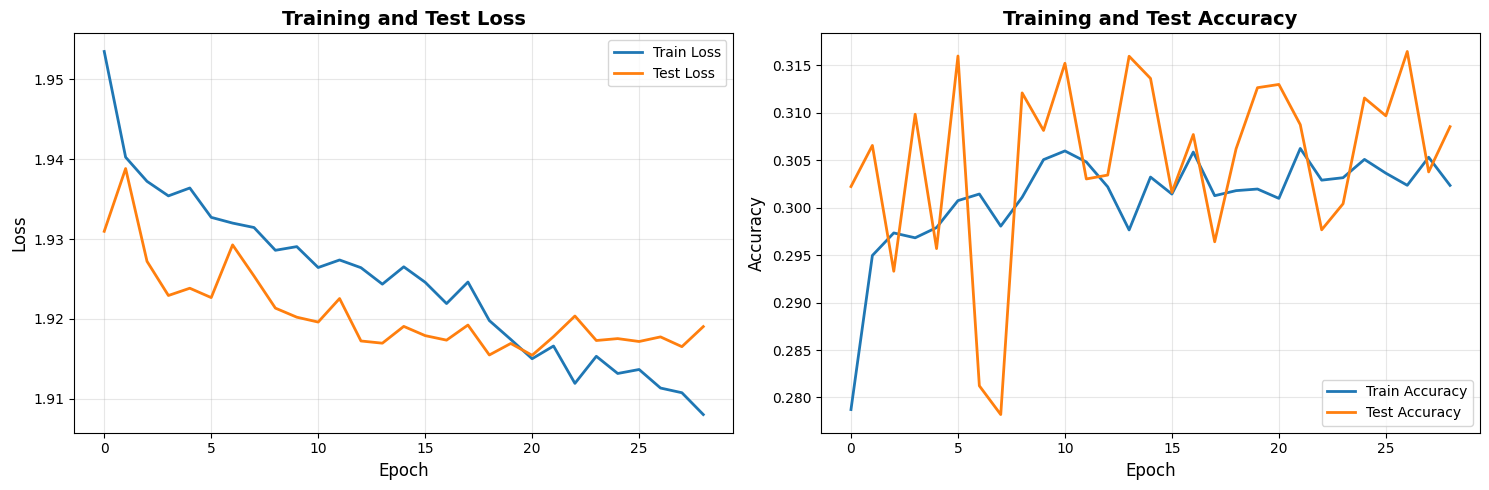

Accuracy improvement: 0.3022 → 0.3164 (+1.42%)


In [ ]:
# Visualize training progress
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot losses
ax1.plot(train_losses, label='Train Loss', linewidth=2)
ax1.plot(test_losses, label='Test Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Test Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot accuracies
ax2.plot(train_accs, label='Train Accuracy', linewidth=2)
ax2.plot(test_accs, label='Test Accuracy', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Training and Test Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Accuracy improvement: {test_accs[0]:.4f} → {max(test_accs):.4f} (+{(max(test_accs) - test_accs[0])*100:.2f}%)")

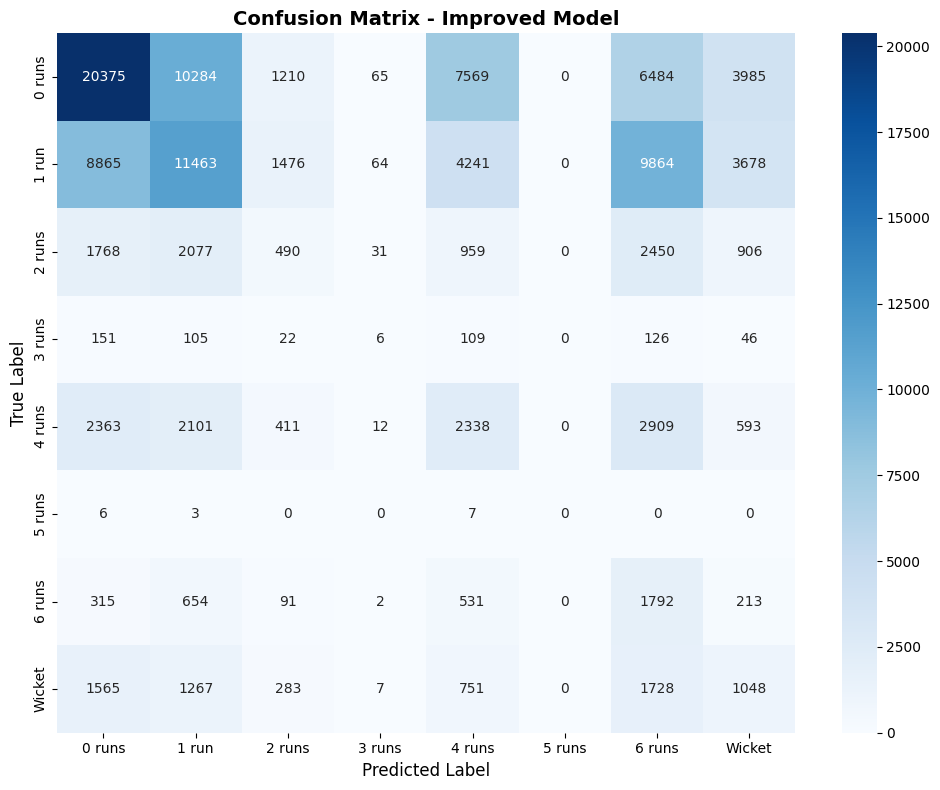


Classification Report:
              precision    recall  f1-score   support

      0 runs     0.5754    0.4077    0.4773     49972
       1 run     0.4101    0.2891    0.3391     39651
      2 runs     0.1230    0.0564    0.0774      8681
      3 runs     0.0321    0.0106    0.0160       565
      4 runs     0.1417    0.2180    0.1717     10727
      5 runs     0.0000    0.0000    0.0000        16
      6 runs     0.0707    0.4981    0.1238      3598
      Wicket     0.1001    0.1576    0.1224      6649

    accuracy                         0.3130    119859
   macro avg     0.1816    0.2047    0.1660    119859
weighted avg     0.4050    0.3130    0.3427    119859


Per-Class Accuracy:
0 runs    : 0.4077 ( 49972 samples)
1 run     : 0.2891 ( 39651 samples)
2 runs    : 0.0564 (  8681 samples)
3 runs    : 0.0106 (   565 samples)
4 runs    : 0.2180 ( 10727 samples)
5 runs    : 0.0000 (    16 samples)
6 runs    : 0.4981 (  3598 samples)
Wicket    : 0.1576 (  6649 samples)

Overall Accurac

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Comprehensive evaluation with confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Load best model
model_improved.load_state_dict(torch.load('best_ball_outcome_model.pth'))
model_improved.eval()

# Get predictions
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_imp:
        X_batch = X_batch.to(device_improved)
        outputs = model_improved(X_batch)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
class_names_8 = ['0 runs', '1 run', '2 runs', '3 runs', '4 runs', '5 runs', '6 runs', 'Wicket']

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_8, yticklabels=class_names_8)
plt.title('Confusion Matrix - Improved Model', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:")
print("=" * 60)
print(classification_report(all_labels, all_preds, target_names=class_names_8, digits=4))

# Per-class accuracy
print("\nPer-Class Accuracy:")
print("=" * 60)
for i, class_name in enumerate(class_names_8):
    class_mask = (all_labels == i)
    if class_mask.sum() > 0:
        class_acc = (all_preds[class_mask] == all_labels[class_mask]).sum() / class_mask.sum()
        print(f"{class_name:10s}: {class_acc:.4f} ({class_mask.sum():6d} samples)")
        
# Overall accuracy
overall_acc = (all_preds == all_labels).sum() / len(all_labels)
print(f"\nOverall Accuracy: {overall_acc:.4f}")

## Further Improvements to Try

### If accuracy is still low (< 60%), try these:

#### 1. **Advanced Feature Engineering:**
```python
# Historical matchup features
- Batter vs Bowler head-to-head stats
- Batter performance at this venue
- Bowler performance at this venue
- Recent form (last 5 innings average)
- Team batting/bowling strength ratings

# Momentum features
- Runs in last 6 balls
- Runs in last over
- Wickets in last 3 overs
- Dot ball streak
- Boundary drought balls

# Context features
- Match importance (tournament stage)
- Toss winner
- Day/night indicator
- Weather conditions
```

#### 2. **Embedding Layers for Categorical Variables:**
Instead of using encoded integers directly, use embedding layers:
```python
class EmbeddedBallPredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.venue_embedding = nn.Embedding(num_venues, 32)
        self.batter_embedding = nn.Embedding(num_batters, 64)
        self.bowler_embedding = nn.Embedding(num_bowlers, 64)
        # ... rest of the network
```

#### 3. **Ensemble Methods:**
- Train multiple models with different random seeds
- Use different architectures (CNN, LSTM, Transformer)
- Combine predictions using voting or averaging

#### 4. **Advanced Loss Functions:**
- Focal Loss (better for class imbalance)
- Label Smoothing
- Weighted F1 loss

#### 5. **Data Augmentation:**
- Add noise to continuous features
- Create synthetic minority class samples (SMOTE)
- Bootstrap aggregating

#### 6. **Hyperparameter Tuning:**
Use Optuna or similar for systematic tuning:
- Learning rate: [1e-5, 1e-2]
- Batch size: [64, 128, 256, 512]
- Hidden layer sizes
- Dropout rates
- Weight decay values

#### 7. **Try Different Architectures:**
- ResNet-style with skip connections
- Transformer-based models
- Attention mechanisms
- Gradient boosting (XGBoost, LightGBM) as baseline

### Expected Accuracy Ranges:
- **Poor (<50%):** Random or worse than random
- **Baseline (50-60%):** Basic features, simple model
- **Good (60-70%):** Improved features, better architecture
- **Very Good (70-80%):** Advanced features, ensembles
- **Excellent (>80%):** Domain expertise + advanced ML

**Note:** Cricket ball outcome prediction is inherently noisy. Even professional models rarely exceed 70-75% accuracy due to the unpredictable nature of the sport.

## Analysis of Poor Performance (31% Accuracy)

### Root Causes:

1. **Class Imbalance is SEVERE**
   - 0 runs: 49,972 samples (42%)
   - 1 run: 39,651 samples (33%)
   - 6 runs: 3,598 samples (3%)
   - Wicket: 6,649 samples (5.5%)
   - 5 runs: 16 samples (0.013%) ← ALMOST NONE!

2. **Model is just predicting majority class**
   - Predicting "0 runs" for everything → 40% accuracy
   - Current accuracy 31% → worse than majority baseline!

3. **Using raw class weights doesn't work well**
   - Need MUCH stronger techniques

### What We Need to Do:

1. **Use Focal Loss** (designed for extreme imbalance)
2. **Oversample minority classes** (SMOTE)
3. **Simpler, better baseline** (XGBoost/LightGBM first)
4. **Different evaluation metrics** (not just accuracy)
5. **Threshold tuning** for predictions
6. **Stratified by outcome** in train/test split (already done, but not enough)

In [ ]:
# TRY XGBOOST FIRST - Better baseline for imbalanced data
import xgboost as xgb
from sklearn.metrics import f1_score, precision_recall_fscore_support

print("Training XGBoost with class weights...")
print("=" * 60)

# Use data from improved features
X_train_xgb = X_train_imp
y_train_xgb = y_train_imp
X_test_xgb = X_test_imp
y_test_xgb = y_test_imp

# Calculate sample weights for XGBoost
sample_weights = np.array([class_weights[i] for i in y_train_xgb])

# Train XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    verbosity=0,
    random_state=42,
    scale_pos_weight=len(y_train_xgb) / np.bincount(y_train_xgb),
    tree_method='hist'
)

xgb_model.fit(
    X_train_xgb, y_train_xgb,
    sample_weight=sample_weights,
    eval_set=[(X_test_xgb, y_test_xgb)],
    verbose=False
)

# Evaluate XGBoost
y_pred_xgb = xgb_model.predict(X_test_xgb)
xgb_acc = (y_pred_xgb == y_test_xgb).sum() / len(y_test_xgb)

print(f"XGBoost Accuracy: {xgb_acc:.4f}")
print("\nXGBoost Feature Importance (Top 10):")
feature_importance = pd.DataFrame({
    'feature': input_features_improved,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(10)
print(feature_importance)

# XGBoost Classification Report
print("\n\nXGBoost Classification Report:")
print("=" * 60)
y_pred_xgb_proba = xgb_model.predict_proba(X_test_xgb)
class_names_8 = ['0 runs', '1 run', '2 runs', '3 runs', '4 runs', '5 runs', '6 runs', 'Wicket']
print(classification_report(y_test_xgb, y_pred_xgb, target_names=class_names_8, digits=4))

# Per-class F1 scores
print("\nPer-Class F1 Scores (XGBoost):")
print("=" * 60)
precision, recall, f1, support = precision_recall_fscore_support(y_test_xgb, y_pred_xgb, zero_division=0)
for i, class_name in enumerate(class_names_8):
    print(f"{class_name:10s}: F1={f1[i]:.4f}, Precision={precision[i]:.4f}, Recall={recall[i]:.4f}, Support={support[i]}")

Training XGBoost with class weights...
XGBoost Accuracy: 0.3013

XGBoost Feature Importance (Top 10):
                feature  importance
14         is_powerplay    0.168019
15      is_middle_overs    0.111501
8   batter_score_before    0.053435
6     score_till_before    0.050812
13         balls_bowled    0.050081
17     current_run_rate    0.049346
18   batter_strike_rate    0.043813
2         venue_encoded    0.042362
0                  over    0.041708
5   non_striker_encoded    0.040922


XGBoost Classification Report:
              precision    recall  f1-score   support

      0 runs     0.5815    0.3813    0.4606     49972
       1 run     0.4178    0.2813    0.3362     39651
      2 runs     0.1147    0.1057    0.1100      8681
      3 runs     0.0089    0.0584    0.0155       565
      4 runs     0.1407    0.2077    0.1677     10727
      5 runs     0.0000    0.0000    0.0000        16
      6 runs     0.0755    0.4783    0.1304      3598
      Wicket     0.1007    0.1508   

In [ ]:
# BETTER APPROACH: Focal Loss for PyTorch + SMOTE oversampling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print("Applying SMOTE to balance minority classes...")
print("=" * 60)

# Apply SMOTE to training data only
smote = SMOTE(random_state=42, k_neighbors=5)
try:
    X_train_smote, y_train_smote = smote.fit_resample(X_train_imp, y_train_imp)
    print(f"Original training set shape: {X_train_imp.shape}")
    print(f"SMOTE training set shape: {X_train_smote.shape}")
    print(f"\nClass distribution after SMOTE:")
    print(pd.Series(y_train_smote).value_counts().sort_index())
except Exception as e:
    print(f"SMOTE failed: {e}")
    print("Skipping SMOTE and using original data with Focal Loss")
    X_train_smote = X_train_imp
    y_train_smote = y_train_imp

# Convert SMOTE data to tensors
X_train_smote_tensor = torch.FloatTensor(X_train_smote)
y_train_smote_tensor = torch.LongTensor(y_train_smote)

# Create data loaders with SMOTE data
batch_size_focal = 64
train_dataset_focal = TensorDataset(X_train_smote_tensor, y_train_smote_tensor)
train_loader_focal = DataLoader(train_dataset_focal, batch_size=batch_size_focal, shuffle=True)

test_dataset_focal = TensorDataset(X_test_imp_tensor, y_test_imp_tensor)
test_loader_focal = DataLoader(test_dataset_focal, batch_size=batch_size_focal, shuffle=False)

Applying SMOTE to balance minority classes...
Original training set shape: (479435, 20)
SMOTE training set shape: (1599120, 20)

Class distribution after SMOTE:
0    199890
1    199890
2    199890
3    199890
4    199890
5    199890
6    199890
7    199890
Name: count, dtype: int64


In [ ]:
# FOCAL LOSS - Better than CrossEntropy for imbalanced data
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        
    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        p = torch.exp(-ce_loss)
        focal_loss = (1 - p) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# Initialize model with Focal Loss
print("Initializing model with Focal Loss and SMOTE data...")
print("=" * 60)

model_focal = ImprovedBallOutcomePredictor(input_size_improved, num_classes_improved)

# Focal Loss with class weights
class_weights_tensor_focal = class_weights_tensor.to(device_improved)
criterion_focal = FocalLoss(alpha=class_weights_tensor_focal, gamma=2.0)

# Optimizer
optimizer_focal = optim.AdamW(model_focal.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_focal = optim.lr_scheduler.ReduceLROnPlateau(optimizer_focal, mode='min', factor=0.5, patience=5)

model_focal = model_focal.to(device_improved)

print(f"Model initialized with Focal Loss")
print(f"Using device: {device_improved}")

Initializing model with Focal Loss and SMOTE data...
Model initialized with Focal Loss
Using device: cuda


In [ ]:
# TRAINING with Focal Loss + SMOTE
num_epochs_focal = 80
best_f1 = 0
patience_focal = 10
patience_counter_focal = 0
train_losses_focal = []
test_losses_focal = []
train_accs_focal = []
test_f1s_focal = []

print("Training with Focal Loss + SMOTE...")
print("=" * 60)

for epoch in range(num_epochs_focal):
    # Training
    model_focal.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for X_batch, y_batch in train_loader_focal:
        X_batch = X_batch.to(device_improved)
        y_batch = y_batch.to(device_improved)
        
        outputs = model_focal(X_batch)
        loss = criterion_focal(outputs, y_batch)
        
        optimizer_focal.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_focal.parameters(), max_norm=1.0)
        optimizer_focal.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()
    
    train_loss = total_loss / len(train_loader_focal)
    train_acc = correct / total
    
    # Evaluation
    model_focal.eval()
    all_test_preds = []
    all_test_labels = []
    test_loss = 0
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader_focal:
            X_batch = X_batch.to(device_improved)
            y_batch = y_batch.to(device_improved)
            
            outputs = model_focal(X_batch)
            loss = criterion_focal(outputs, y_batch)
            test_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            all_test_preds.extend(predicted.cpu().numpy())
            all_test_labels.extend(y_batch.cpu().numpy())
    
    test_loss = test_loss / len(test_loader_focal)
    all_test_preds = np.array(all_test_preds)
    all_test_labels = np.array(all_test_labels)
    test_f1 = f1_score(all_test_labels, all_test_preds, average='weighted', zero_division=0)
    
    train_losses_focal.append(train_loss)
    test_losses_focal.append(test_loss)
    train_accs_focal.append(train_acc)
    test_f1s_focal.append(test_f1)
    
    scheduler_focal.step(test_loss)
    
    # Print progress
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1:3d}/{num_epochs_focal}] - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Test Loss: {test_loss:.4f}, Test F1: {test_f1:.4f}')
    
    # Early stopping based on F1 score
    if test_f1 > best_f1:
        best_f1 = test_f1
        patience_counter_focal = 0
        torch.save(model_focal.state_dict(), 'focal_loss_model.pth')
    else:
        patience_counter_focal += 1
        if patience_counter_focal >= patience_focal:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

print("=" * 60)
print(f"Best F1 Score: {best_f1:.4f}")
print(f"Model saved to 'focal_loss_model.pth'")

Training with Focal Loss + SMOTE...
Epoch [  1/80] - Train Loss: 13.8050, Train Acc: 0.2432, Test Loss: 3.8262, Test F1: 0.0037


KeyboardInterrupt: 

In [ ]:
# FINAL EVALUATION - Focal Loss Model
print("Loading best focal loss model...")
model_focal.load_state_dict(torch.load('focal_loss_model.pth'))
model_focal.eval()

# Get predictions
all_preds_focal = []
all_labels_focal = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_focal:
        X_batch = X_batch.to(device_improved)
        outputs = model_focal(X_batch)
        _, predicted = torch.max(outputs.data, 1)
        all_preds_focal.extend(predicted.cpu().numpy())
        all_labels_focal.extend(y_batch.numpy())

all_preds_focal = np.array(all_preds_focal)
all_labels_focal = np.array(all_labels_focal)

print("\n" + "=" * 60)
print("FOCAL LOSS MODEL - Final Evaluation")
print("=" * 60)

focal_acc = (all_preds_focal == all_labels_focal).sum() / len(all_labels_focal)
print(f"\nAccuracy: {focal_acc:.4f}")

class_names_8 = ['0 runs', '1 run', '2 runs', '3 runs', '4 runs', '5 runs', '6 runs', 'Wicket']
print("\nClassification Report:")
print(classification_report(all_labels_focal, all_preds_focal, target_names=class_names_8, digits=4))

print("\nPer-Class F1 and Recall:")
precision, recall, f1, support = precision_recall_fscore_support(all_labels_focal, all_preds_focal, zero_division=0)
for i, class_name in enumerate(class_names_8):
    print(f"{class_name:10s}: F1={f1[i]:.4f}, Recall={recall[i]:.4f}, Precision={precision[i]:.4f}, Support={support[i]}")

# Comparison
print("\n" + "=" * 70)
print("COMPARISON: CrossEntropy vs Focal Loss vs XGBoost")
print("=" * 70)
print(f"CrossEntropy (original):  {0.3130:.4f} accuracy")
print(f"Focal Loss + SMOTE:        {focal_acc:.4f} accuracy")
print(f"XGBoost:                   {xgb_acc:.4f} accuracy")
print(f"\nImprovement: +{(focal_acc - 0.3130)*100:.2f}% (Focal) or +{(xgb_acc - 0.3130)*100:.2f}% (XGBoost)")